# Setup

In [64]:
# To support both python 2 and python 3
from __future__ import division, print_function, unicode_literals

# common imports
import numpy as np
import os

# to make this notebook's output stable across runs
np.random.seed(42)

# To plot pretty figures
%matplotlib inline
import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12

# Where to save the figures
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "training_linear_models"


def save_fig(fig_id, tight_layout=True):
    path = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID, fig_id + ".png")
    print("saving figure ", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format="png", dpi=300)
    

# Linear Regression Using the Normal Equation

In [65]:
import numpy as np

#Uniformly distributed array with dimensions (100, 1)
X = 2 * np.random.rand(100, 1)

# Normally distributed array with noise
y = 4 + 3 * X + np.random.randn(100, 1)

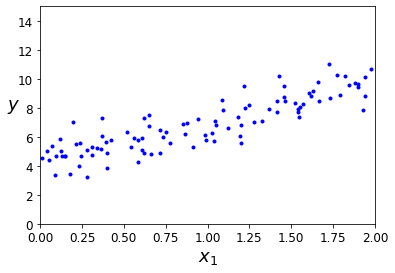

In [66]:
plt.plot(X, y, "b.")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation = 0, fontsize=18)
plt.axis([0, 2, 0, 15])
plt.show()

In [67]:
print(X.shape)
print("============")
print(y.shape)
print("============")
np.ones((1,2,3,4))

(100, 1)
(100, 1)


array([[[[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]],

        [[1., 1., 1., 1.],
         [1., 1., 1., 1.],
         [1., 1., 1., 1.]]]])

In [68]:
# Add bias term  x0=1

X_b = np.c_[np.ones((100,1)), X] # add x0 = 1 to each instance
X_b

array([[1.        , 0.74908024],
       [1.        , 1.90142861],
       [1.        , 1.46398788],
       [1.        , 1.19731697],
       [1.        , 0.31203728],
       [1.        , 0.31198904],
       [1.        , 0.11616722],
       [1.        , 1.73235229],
       [1.        , 1.20223002],
       [1.        , 1.41614516],
       [1.        , 0.04116899],
       [1.        , 1.9398197 ],
       [1.        , 1.66488528],
       [1.        , 0.42467822],
       [1.        , 0.36364993],
       [1.        , 0.36680902],
       [1.        , 0.60848449],
       [1.        , 1.04951286],
       [1.        , 0.86389004],
       [1.        , 0.58245828],
       [1.        , 1.22370579],
       [1.        , 0.27898772],
       [1.        , 0.5842893 ],
       [1.        , 0.73272369],
       [1.        , 0.91213997],
       [1.        , 1.57035192],
       [1.        , 0.39934756],
       [1.        , 1.02846888],
       [1.        , 1.18482914],
       [1.        , 0.09290083],
       [1.

In [69]:
# Compute Theta hat

# Apply the normal equation
# inv() function from Numpy's Linear Algebra module (np.linalg) to compute the inverse of the dot() method for 
# matrix multiplication

theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y)
theta_best

array([[4.21509616],
       [2.77011339]])

In [70]:
X1_b = np.array([
    [1, 1],
    [1, 2],
    [1, 3],
    [1, 4]])

y1 = np.array([6, 5, 7,10])

theta_best = np.linalg.inv(X1_b.T.dot(X1_b)).dot(X1_b.T).dot(y1)
theta_best

array([3.5, 1.4])

In [71]:
# Lets make predictions using theta_best

X_new = np.array([[0], [2]])
X_new_b = np.c_[np.ones((2,1)), X_new] # add x0 to each instance
y_predict = X_new_b.dot(theta_best)
y_predict

array([3.5, 6.3])

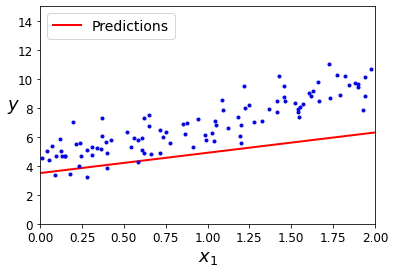

In [72]:
# Lets plot the model's predictions

plt.plot(X_new, y_predict, "r-", linewidth=2, label="Predictions")
plt.plot(X, y, "b.")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.legend(loc="upper left", fontsize=14)
plt.axis([0, 2, 0, 15])
plt.show()

In [73]:
# Equivalent code in Scikit-Learn

from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X, y)
lin_reg.intercept_, lin_reg.coef_

(array([4.21509616]), array([[2.77011339]]))

In [74]:
lin_reg.predict(X_new)

array([[4.21509616],
       [9.75532293]])

# Linear Regression using batch gradient descent

In [75]:
X_b.shape

(100, 2)

In [76]:
y.shape

(100, 1)

In [77]:
# Differentiattion function

def mydiff(f, x):
    d = 0.000001
    return (f(x+d)-f(x))/d

In [78]:
def sq(x): 
    return x*x
    
def cb(x): 
    return x*x*x

In [79]:
mydiff(cb, 2)

12.000006002210739

In [80]:
eta = 0.01 # Learning rate
n_iterations = 100 #Number of Iterations
m = 100 # Number of elements in training set
theta = np.random.randn(2, 1) # Random initialization of weights

for iteration in range(n_iterations):
    gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
    theta = theta - eta * gradients
    if iteration % 50:
        print(theta)
        
#y = 4 + 3 * X + np.random.randn(100, 1)

[[0.22633422]
 [1.67181808]]
[[0.32676535]
 [1.77395782]]
[[0.42326689]
 [1.8716864 ]]
[[0.5160004 ]
 [1.96518667]]
[[0.60512075]
 [2.05463391]]
[[0.69077645]
 [2.14019616]]
[[0.77310984]
 [2.22203453]]
[[0.85225741]
 [2.30030345]]
[[0.92835001]
 [2.37515099]]
[[1.00151308]
 [2.44671909]]
[[1.0718669 ]
 [2.51514384]]
[[1.13952675]
 [2.58055569]]
[[1.20460319]
 [2.64307972]]
[[1.26720221]
 [2.70283582]]
[[1.32742539]
 [2.75993895]]
[[1.38537016]
 [2.81449929]]
[[1.4411299]
 [2.8666225]]
[[1.49479416]
 [2.91640985]]
[[1.54644877]
 [2.96395843]]
[[1.59617603]
 [3.00936133]]
[[1.64405484]
 [3.05270779]]
[[1.69016085]
 [3.09408334]]
[[1.73456657]
 [3.13357001]]
[[1.77734155]
 [3.17124641]]
[[1.81855245]
 [3.20718793]]
[[1.85826316]
 [3.24146681]]
[[1.89653497]
 [3.27415234]]
[[1.93342661]
 [3.30531092]]
[[1.96899442]
 [3.33500621]]
[[2.00329239]
 [3.36329925]]
[[2.03637228]
 [3.39024855]]
[[2.06828373]
 [3.4159102 ]]
[[2.09907433]
 [3.44033798]]
[[2.1287897 ]
 [3.46358343]]
[[2.15747358]
 [

In [81]:
 len(X_b)

100

In [82]:
X_new_b.dot(theta)

array([[ 2.96262018],
       [10.5664785 ]])

In [83]:
X_new_b = X_b

In [84]:
X_new = X

saving figure  gradient_descent_plot


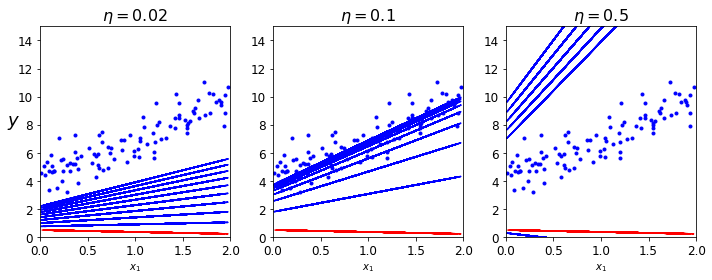

In [85]:
# Plot Gradient descent for various learning rates

theta_path_bgd = []

def plot_gradient_descent(theta, eta, theta_path=None):
    m = len(X_b)
    plt.plot(X, y, "b.")
    n_iterations = 1000
    for iteration in range(n_iterations):
        if iteration < 10:
            y_predict = X_new_b.dot(theta)
            style = "b-" if iteration > 0 else "r--"
            plt.plot(X_new, y_predict, style)
        gradients = 2/m * X_b.T.dot(X_b.dot(theta) - y)
        theta = theta - eta * gradients
        if theta_path is not None:
            theta_path.append(theta)
    plt.xlabel("$x_1$", fontsize = 10)
    plt.axis([0, 2, 0, 15])
    plt.title(r"$\eta = {}$".format(eta), fontsize=16)
    
np.random.seed(42)
theta = np.random.randn(2, 1) # random initialization

plt.figure(figsize=(10, 4))
plt.subplot(131); plot_gradient_descent(theta, eta=0.02)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.subplot(132); plot_gradient_descent(theta, eta=0.1, theta_path=theta_path_bgd)
plt.subplot(133); plot_gradient_descent(theta, eta=0.5)

save_fig("gradient_descent_plot")
plt.show()

# Got the error - FileNotFoundError: [Errno 2] No such file or directory: 
# './images/training_linear_models/gradient_descent_plot.png' - hence manually created folder images/training_linear_models 

saving figure  gradient_descent_plot


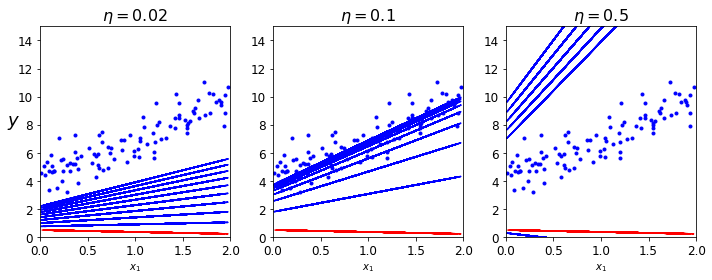

In [86]:
np.random.seed(42)
theta = np.random.randn(2, 1)

plt.figure(figsize=(10, 4))
plt.subplot(131); plot_gradient_descent(theta, eta=0.02)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.subplot(132); plot_gradient_descent(theta, eta=0.1, theta_path=theta_path_bgd)
plt.subplot(133); plot_gradient_descent(theta, eta=0.5)
    
save_fig("gradient_descent_plot")
plt.show()

# Stochastic Gradient Descent

In [87]:
# Lets implement SGD

theta_path_sgd = []
m = len(X_b)
np.random.seed(42)

saving figure  sgd_plot


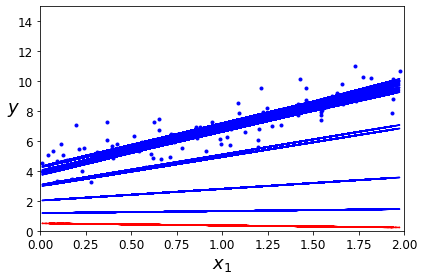

In [88]:
n_epochs = 50
t0, t1 = 5, 50 # learning schedule hyperparameters

def learning_schedule(t):
    return t0/(t+t1)

theta= np.random.randn(2, 1) # random initialization
theta_path_sgd = []
for epoch in range(n_epochs):
    for i in range(m):
        if epoch ==0 and i < 20:
            y_predict = X_new_b.dot(theta)
            style = "b-" if i>0 else "r--"
            plt.plot(X_new, y_predict, style)
        random_index = np.random.randint(m)
        xi = X_b[random_index:random_index+1]
        yi = y[random_index:random_index+1]
        gradients = 2 * xi.T.dot(xi.dot(theta)-yi)
        eta = learning_schedule(epoch * m + i)
        theta = theta - eta * gradients
        theta_path_sgd.append(theta)
        
plt.plot(X, y, 'b.')
plt.xlabel("$x_1$", fontsize = 18)
plt.ylabel("$y$", rotation = 0, fontsize=18)
plt.axis([0, 2, 0, 15])
save_fig("sgd_plot")
plt.show()



In [89]:
theta

array([[4.21076011],
       [2.74856079]])

In [90]:
y1 = np.array([1,2,3])
print(y1)
print(y1.ravel())

[1 2 3]
[1 2 3]


In [91]:
y

array([[ 6.33428778],
       [ 9.40527849],
       [ 8.48372443],
       [ 5.60438199],
       [ 4.71643995],
       [ 5.29307969],
       [ 5.82639572],
       [ 8.67878666],
       [ 6.79819647],
       [ 7.74667842],
       [ 5.03890908],
       [10.14821022],
       [ 8.46489564],
       [ 5.7873021 ],
       [ 5.18802735],
       [ 6.06907205],
       [ 5.12340036],
       [ 6.82087644],
       [ 6.19956196],
       [ 4.28385989],
       [ 7.96723765],
       [ 5.09801844],
       [ 5.75798135],
       [ 5.96358393],
       [ 5.32104916],
       [ 8.29041045],
       [ 4.85532818],
       [ 6.28312936],
       [ 7.3932017 ],
       [ 4.68275333],
       [ 9.53145501],
       [ 5.19772255],
       [ 4.64785995],
       [ 9.61886731],
       [ 7.87502098],
       [ 8.82387021],
       [ 5.88791282],
       [ 7.0492748 ],
       [ 7.91303719],
       [ 6.9424623 ],
       [ 4.69751764],
       [ 5.80238342],
       [ 5.34915394],
       [10.20785545],
       [ 6.34371184],
       [ 7

In [92]:
# ravel() converts multi-dimensional array to single dimensional array
y.ravel()

array([ 6.33428778,  9.40527849,  8.48372443,  5.60438199,  4.71643995,
        5.29307969,  5.82639572,  8.67878666,  6.79819647,  7.74667842,
        5.03890908, 10.14821022,  8.46489564,  5.7873021 ,  5.18802735,
        6.06907205,  5.12340036,  6.82087644,  6.19956196,  4.28385989,
        7.96723765,  5.09801844,  5.75798135,  5.96358393,  5.32104916,
        8.29041045,  4.85532818,  6.28312936,  7.3932017 ,  4.68275333,
        9.53145501,  5.19772255,  4.64785995,  9.61886731,  7.87502098,
        8.82387021,  5.88791282,  7.0492748 ,  7.91303719,  6.9424623 ,
        4.69751764,  5.80238342,  5.34915394, 10.20785545,  6.34371184,
        7.06574625,  7.27306077,  5.71855706,  7.86711877,  7.29958236,
        8.82697144,  8.08449921,  9.73664501,  8.86548845,  6.03673644,
        9.59980838,  3.4686513 ,  5.64948961,  3.3519395 ,  7.50191639,
        5.54881045,  5.30603267,  9.78594227,  4.90965564,  5.91306699,
        8.56331925,  3.23806212,  8.99781574,  4.70718666, 10.70

In [93]:
# Linear Regression using Scikit_Learn's SGDRegressor Class

from sklearn.linear_model import SGDRegressor
sgd_reg = SGDRegressor(max_iter=50, penalty=None, eta0=0.1, random_state=42)
sgd_reg.fit(X, y.ravel())

SGDRegressor(alpha=0.0001, average=False, early_stopping=False, epsilon=0.1,
             eta0=0.1, fit_intercept=True, l1_ratio=0.15,
             learning_rate='invscaling', loss='squared_loss', max_iter=50,
             n_iter_no_change=5, penalty=None, power_t=0.25, random_state=42,
             shuffle=True, tol=0.001, validation_fraction=0.1, verbose=0,
             warm_start=False)

In [94]:
sgd_reg.intercept_, sgd_reg.coef_

(array([4.24365286]), array([2.8250878]))

# Mini-batch gradient Descent

In [95]:
# let's implement Mini-batch gradient descnet

theta_path_mgd = []

n_iterations = 50
minibatch_size = 20

np.random.seed(42)
theta = np.random.randn(2, 1) # random initialization

t0, t1 = 10, 1000
def learning_schedule(t):
    return t0/(t1 + t)

t = 0
for epoch in range(n_iterations):
    shuffled_indices = np.random.permutation(m)
    X_b_shuffled = X_b[shuffled_indices]
    y_shuffled = y[shuffled_indices]
    for i in range(0, m, minibatch_size):
        t+=1
        xi = X_b_shuffled[i:i+minibatch_size]
        yi = y_shuffled[i:i+minibatch_size]
        gradients = 2 * xi.T.dot(xi.dot(theta)-yi)
        eta = learning_schedule(t)
        theta = theta - eta * gradients
        theta_path_mgd.append(theta)
        
theta

array([[4.25214635],
       [2.7896408 ]])

In [96]:
# Lets implement Mini-batch gradient descent

theta_path_mgd = []

n_iterations = 50000
minibatch_size = 20

np.random.seed(42)
theta = np.random.randn(2, 1)  # random initialization

t0, t1 = 10, 1000
def learning_schedule(t):
    return t0/(t+t1)

t = 0
for epoch in range(n_iterations):
    shuffled_indices = np.random.permutation(m)
    X_b_shuffled = X_b[shuffled_indices]
    y_shuffled = y[shuffled_indices]
    xi = X_b_shuffled[:minibatch_size]
    yi = y_shuffled[:minibatch_size]
    gradients = 2 * xi.T.dot(xi.dot(theta)-yi)
    eta = learning_schedule(t)
    print("eta %s" % eta)
    theta = theta - eta * gradients
    print(theta)
    theta_path_mgd.append(theta)
        
theta

eta 0.01
[[3.25520613]
 [3.11909158]]
eta 0.01
[[3.5961088]
 [3.3630237]]
eta 0.01
[[3.69592867]
 [3.34817087]]
eta 0.01
[[3.67049406]
 [3.22470198]]
eta 0.01
[[3.762869  ]
 [3.13865852]]
eta 0.01
[[3.88525691]
 [3.21459324]]
eta 0.01
[[3.9164466 ]
 [3.09058057]]
eta 0.01
[[3.93467444]
 [3.00372498]]
eta 0.01
[[4.00730459]
 [3.04201798]]
eta 0.01
[[3.97954638]
 [2.88092806]]
eta 0.01
[[4.07608056]
 [2.96386553]]
eta 0.01
[[4.0904702 ]
 [2.95048801]]
eta 0.01
[[4.12045018]
 [2.97637742]]
eta 0.01
[[4.17175773]
 [2.94539176]]
eta 0.01
[[4.20668454]
 [2.99961411]]
eta 0.01
[[4.24728247]
 [2.98694443]]
eta 0.01
[[4.06562427]
 [2.78557683]]
eta 0.01
[[4.11007313]
 [2.79484488]]
eta 0.01
[[4.13613484]
 [2.81490705]]
eta 0.01
[[4.10273832]
 [2.75295503]]
eta 0.01
[[4.10160862]
 [2.77164287]]
eta 0.01
[[4.1510654 ]
 [2.81135001]]
eta 0.01
[[4.22261987]
 [2.86922202]]
eta 0.01
[[4.16621067]
 [2.86290352]]
eta 0.01
[[4.05271192]
 [2.80513152]]
eta 0.01
[[4.01410196]
 [2.71193602]]
eta 0.01
[[4.0

eta 0.01
[[4.0770959 ]
 [2.61027585]]
eta 0.01
[[4.05778986]
 [2.66281428]]
eta 0.01
[[4.27357215]
 [2.90587534]]
eta 0.01
[[4.20292969]
 [2.85725845]]
eta 0.01
[[4.28806261]
 [2.88106347]]
eta 0.01
[[4.18502257]
 [2.732132  ]]
eta 0.01
[[4.16001069]
 [2.76887024]]
eta 0.01
[[4.10012804]
 [2.75799745]]
eta 0.01
[[4.21306815]
 [2.91398737]]
eta 0.01
[[4.22530613]
 [2.84393422]]
eta 0.01
[[4.13495316]
 [2.79201261]]
eta 0.01
[[4.24579122]
 [2.9188021 ]]
eta 0.01
[[4.26882919]
 [2.86737683]]
eta 0.01
[[4.29537699]
 [2.89710977]]
eta 0.01
[[4.24197997]
 [2.86280052]]
eta 0.01
[[4.29533265]
 [2.89371182]]
eta 0.01
[[4.20317634]
 [2.8267184 ]]
eta 0.01
[[4.09029484]
 [2.70432746]]
eta 0.01
[[4.15424963]
 [2.75782121]]
eta 0.01
[[4.18858717]
 [2.79641738]]
eta 0.01
[[4.21823552]
 [2.9028086 ]]
eta 0.01
[[4.23383387]
 [2.93110633]]
eta 0.01
[[4.21063808]
 [2.89085413]]
eta 0.01
[[4.09499621]
 [2.77232973]]
eta 0.01
[[4.30569192]
 [2.96919935]]
eta 0.01
[[4.13543594]
 [2.801354  ]]
eta 0.01
[[4

eta 0.01
[[4.20609409]
 [2.66901439]]
eta 0.01
[[4.29277513]
 [2.72790246]]
eta 0.01
[[4.37993594]
 [2.85525167]]
eta 0.01
[[4.15666852]
 [2.63241805]]
eta 0.01
[[4.21477464]
 [2.71257615]]
eta 0.01
[[4.24435643]
 [2.75595912]]
eta 0.01
[[4.18814602]
 [2.68122513]]
eta 0.01
[[4.22452156]
 [2.73455569]]
eta 0.01
[[4.21578383]
 [2.73516986]]
eta 0.01
[[4.16103684]
 [2.69808352]]
eta 0.01
[[4.2496607 ]
 [2.83189069]]
eta 0.01
[[4.28452979]
 [2.83496913]]
eta 0.01
[[4.35484587]
 [2.80214373]]
eta 0.01
[[4.19252839]
 [2.59454183]]
eta 0.01
[[4.33194633]
 [2.70894578]]
eta 0.01
[[4.3782901 ]
 [2.69974349]]
eta 0.01
[[4.51584364]
 [2.95620143]]
eta 0.01
[[4.43995619]
 [2.88430354]]
eta 0.01
[[4.34210278]
 [2.79583746]]
eta 0.01
[[4.28149564]
 [2.6821323 ]]
eta 0.01
[[4.43100144]
 [2.77807868]]
eta 0.01
[[4.43687399]
 [2.72668126]]
eta 0.01
[[4.41018487]
 [2.67835423]]
eta 0.01
[[4.41458901]
 [2.72010136]]
eta 0.01
[[4.33486598]
 [2.7107301 ]]
eta 0.01
[[4.27595073]
 [2.66494497]]
eta 0.01
[[4

eta 0.01
[[4.20051797]
 [2.8493423 ]]
eta 0.01
[[3.99490783]
 [2.584739  ]]
eta 0.01
[[4.07842628]
 [2.6891804 ]]
eta 0.01
[[4.19189225]
 [2.87989257]]
eta 0.01
[[4.16475036]
 [2.85315246]]
eta 0.01
[[4.10239542]
 [2.80144603]]
eta 0.01
[[4.18938623]
 [2.89625702]]
eta 0.01
[[4.2672765 ]
 [2.86816783]]
eta 0.01
[[4.13824345]
 [2.81831374]]
eta 0.01
[[4.27646819]
 [3.00084089]]
eta 0.01
[[4.12600349]
 [2.78684067]]
eta 0.01
[[4.15348058]
 [2.73951504]]
eta 0.01
[[4.12353792]
 [2.75649687]]
eta 0.01
[[4.2578212 ]
 [2.95821966]]
eta 0.01
[[4.18761532]
 [2.90035247]]
eta 0.01
[[4.17664542]
 [2.88793027]]
eta 0.01
[[4.22200599]
 [2.88544816]]
eta 0.01
[[4.25702463]
 [2.89350587]]
eta 0.01
[[4.10108787]
 [2.74714527]]
eta 0.01
[[4.18113732]
 [2.81203317]]
eta 0.01
[[4.18978903]
 [2.81069542]]
eta 0.01
[[4.15809195]
 [2.75138869]]
eta 0.01
[[4.21359416]
 [2.88902795]]
eta 0.01
[[4.03426848]
 [2.64733068]]
eta 0.01
[[4.13268704]
 [2.77829109]]
eta 0.01
[[4.26045733]
 [2.88164615]]
eta 0.01
[[4

eta 0.01
[[4.36906878]
 [2.55439967]]
eta 0.01
[[4.42988799]
 [2.68023399]]
eta 0.01
[[4.403925  ]
 [2.61960985]]
eta 0.01
[[4.32056978]
 [2.5479771 ]]
eta 0.01
[[4.35726556]
 [2.62796849]]
eta 0.01
[[4.27800297]
 [2.58796247]]
eta 0.01
[[4.35710951]
 [2.63214733]]
eta 0.01
[[4.46431352]
 [2.78241054]]
eta 0.01
[[4.24801576]
 [2.60586218]]
eta 0.01
[[4.36796454]
 [2.72892315]]
eta 0.01
[[4.34262801]
 [2.66916521]]
eta 0.01
[[4.33450507]
 [2.72711818]]
eta 0.01
[[4.29811247]
 [2.67566903]]
eta 0.01
[[4.34024722]
 [2.67289021]]
eta 0.01
[[4.4568372 ]
 [2.81432765]]
eta 0.01
[[4.29782896]
 [2.66977837]]
eta 0.01
[[4.39836409]
 [2.76338422]]
eta 0.01
[[4.33275133]
 [2.67555437]]
eta 0.01
[[4.39049323]
 [2.78109971]]
eta 0.01
[[4.21869239]
 [2.6068318 ]]
eta 0.01
[[4.26492387]
 [2.62413709]]
eta 0.01
[[4.27878032]
 [2.66526356]]
eta 0.01
[[4.36505404]
 [2.69835177]]
eta 0.01
[[4.30523082]
 [2.73342389]]
eta 0.01
[[4.4012521 ]
 [2.77952945]]
eta 0.01
[[4.30411243]
 [2.75991891]]
eta 0.01
[[4

...

eta 0.01
[[4.22362056]
 [2.92090601]]
eta 0.01
[[4.19224223]
 [2.83909946]]
eta 0.01
[[4.21887014]
 [2.83293767]]
eta 0.01
[[4.1913585 ]
 [2.86995123]]
eta 0.01
[[4.32259094]
 [3.07965272]]
eta 0.01
[[4.12297846]
 [2.85603752]]
eta 0.01
[[4.20774704]
 [2.88032137]]
eta 0.01
[[4.30191057]
 [2.91671025]]
eta 0.01
[[4.17109712]
 [2.787962  ]]
eta 0.01
[[4.08985002]
 [2.70748064]]
eta 0.01
[[4.15646079]
 [2.70867211]]
eta 0.01
[[4.25905016]
 [2.77985234]]
eta 0.01
[[4.21540635]
 [2.69967371]]
eta 0.01
[[4.22036701]
 [2.76292479]]
eta 0.01
[[4.31509868]
 [2.81474564]]
eta 0.01
[[4.31676813]
 [2.78386544]]
eta 0.01
[[4.27109909]
 [2.74024443]]
eta 0.01
[[4.29237782]
 [2.83481079]]
eta 0.01
[[4.15618918]
 [2.73411759]]
eta 0.01
[[4.22067709]
 [2.80903218]]
eta 0.01
[[4.20793023]
 [2.7830728 ]]
eta 0.01
[[4.27640148]
 [2.85436122]]
eta 0.01
[[4.14534024]
 [2.76374655]]
eta 0.01
[[4.19789069]
 [2.87922718]]
eta 0.01
[[4.23178203]
 [2.8547695 ]]
eta 0.01
[[4.17587197]
 [2.8132645 ]]
eta 0.01
[[4

eta 0.01
[[4.11763235]
 [2.70664491]]
eta 0.01
[[4.08790183]
 [2.7351416 ]]
eta 0.01
[[4.10894584]
 [2.75370244]]
eta 0.01
[[4.22889867]
 [2.77125181]]
eta 0.01
[[4.17640204]
 [2.68683867]]
eta 0.01
[[4.14144477]
 [2.68176817]]
eta 0.01
[[4.20631126]
 [2.75067834]]
eta 0.01
[[4.14193184]
 [2.72709543]]
eta 0.01
[[4.1706671 ]
 [2.84124854]]
eta 0.01
[[4.1752045 ]
 [2.84417732]]
eta 0.01
[[4.0931884 ]
 [2.72153803]]
eta 0.01
[[4.20129151]
 [2.81003585]]
eta 0.01
[[4.25593268]
 [2.85671597]]
eta 0.01
[[4.15246323]
 [2.79758585]]
eta 0.01
[[4.05488313]
 [2.73304641]]
eta 0.01
[[4.13356003]
 [2.83441444]]
eta 0.01
[[4.13862981]
 [2.85445702]]
eta 0.01
[[4.05838837]
 [2.68398054]]
eta 0.01
[[4.11554455]
 [2.77395916]]
eta 0.01
[[4.25006109]
 [2.96004904]]
eta 0.01
[[4.17352223]
 [2.90729202]]
eta 0.01
[[4.10067121]
 [2.85836548]]
eta 0.01
[[3.99599479]
 [2.69956731]]
eta 0.01
[[4.10878019]
 [2.77624131]]
eta 0.01
[[4.03031756]
 [2.67985237]]
eta 0.01
[[4.06075267]
 [2.74004073]]
eta 0.01
[[4

 [2.70505653]]
eta 0.01
[[4.34312215]
 [2.83889256]]
eta 0.01
[[4.21288367]
 [2.67717523]]
eta 0.01
[[4.17540345]
 [2.66197423]]
eta 0.01
[[4.2605291 ]
 [2.72165317]]
eta 0.01
[[4.26317935]
 [2.70970573]]
eta 0.01
[[4.22677406]
 [2.66445273]]
eta 0.01
[[4.14917272]
 [2.66418465]]
eta 0.01
[[4.24588145]
 [2.72987724]]
eta 0.01
[[4.23841891]
 [2.69062009]]
eta 0.01
[[4.30209364]
 [2.72385828]]
eta 0.01
[[4.36267161]
 [2.76468786]]
eta 0.01
[[4.27337618]
 [2.70557723]]
eta 0.01
[[4.2110334 ]
 [2.63183427]]
eta 0.01
[[4.19383392]
 [2.63406629]]
eta 0.01
[[4.16914404]
 [2.56915395]]
eta 0.01
[[4.28533024]
 [2.70066437]]
eta 0.01
[[4.29850154]
 [2.75508385]]
eta 0.01
[[4.3052393 ]
 [2.71596577]]
eta 0.01
[[4.26182791]
 [2.76490856]]
eta 0.01
[[4.38741484]
 [2.84920537]]
eta 0.01
[[4.46253856]
 [2.91868429]]
eta 0.01
[[4.34243997]
 [2.78917558]]
eta 0.01
[[4.35217862]
 [2.78069553]]
eta 0.01
[[4.24000201]
 [2.71607088]]
eta 0.01
[[4.21296529]
 [2.68824403]]
eta 0.01
[[4.25483221]
 [2.72254682

eta 0.01
[[4.16615172]
 [2.88089006]]
eta 0.01
[[4.32842453]
 [2.98050494]]
eta 0.01
[[4.23359972]
 [2.89195321]]
eta 0.01
[[4.16685778]
 [2.8398717 ]]
eta 0.01
[[4.22612841]
 [2.97052448]]
eta 0.01
[[4.19861599]
 [2.88958512]]
eta 0.01
[[4.19668191]
 [2.93663673]]
eta 0.01
[[4.19724782]
 [2.86489361]]
eta 0.01
[[4.25778215]
 [2.86179264]]
eta 0.01
[[4.19342924]
 [2.74920205]]
eta 0.01
[[4.15477389]
 [2.69572819]]
eta 0.01
[[4.14532584]
 [2.67676186]]
eta 0.01
[[4.12572288]
 [2.6638796 ]]
eta 0.01
[[4.20623436]
 [2.75713774]]
eta 0.01
[[4.18296298]
 [2.75528593]]
eta 0.01
[[4.17492457]
 [2.68333835]]
eta 0.01
[[4.13012191]
 [2.71309569]]
eta 0.01
[[4.2007945 ]
 [2.76287124]]
eta 0.01
[[4.33218754]
 [2.84055108]]
eta 0.01
[[4.35529132]
 [2.84358848]]
eta 0.01
[[4.36606334]
 [2.88733667]]
eta 0.01
[[4.2714658 ]
 [2.74636347]]
eta 0.01
[[4.35926066]
 [2.8294333 ]]
eta 0.01
[[4.23989096]
 [2.64654601]]
eta 0.01
[[4.35471965]
 [2.69512131]]
eta 0.01
[[4.30481531]
 [2.70968753]]
eta 0.01
[[4

array([[4.2059341],
       [2.7478481]])

saving figure  gradient_descent_paths_plot


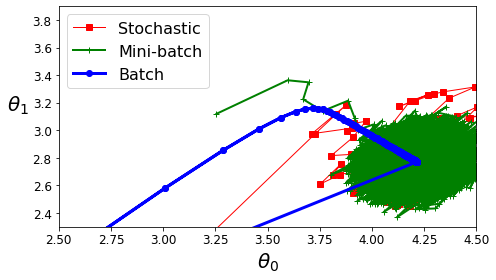

In [97]:
# Plot paths taken by the 3 GD algorithms during training

theta_path_bgd = np.array(theta_path_bgd)
theta_path_sgd = np.array(theta_path_sgd)
theta_path_mgd = np.array(theta_path_mgd)

plt.figure(figsize=(7, 4))
plt.plot(theta_path_sgd[:,0], theta_path_sgd[:, 1], "r-s", linewidth=1, label="Stochastic")
plt.plot(theta_path_mgd[:,0], theta_path_mgd[:, 1], "g-+", linewidth=2, label="Mini-batch")
plt.plot(theta_path_bgd[:,0], theta_path_bgd[:, 1], "b-o", linewidth=3, label="Batch")

plt.legend(loc="upper left", fontsize = 16)
plt.xlabel(r"$\theta_0$", fontsize=20)
plt.ylabel(r"$\theta_1$    ", fontsize=20, rotation=0)
plt.axis([2.5, 4.5, 2.3, 3.9])
save_fig("gradient_descent_paths_plot")
plt.show()

# Polynomial Regression

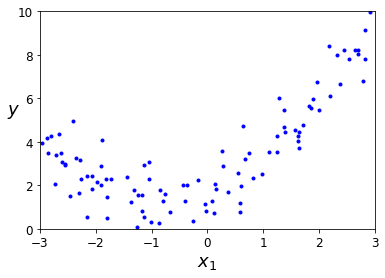

In [98]:
# Implement Polynomial Regression
# Generate nonlinear and noisy dataset

import numpy as np
import numpy.random as rnd

np.random.seed(42)

m=100
X=6 * np.random.rand(m, 1) - 3
y=0.5 * X**2 + X + 2 + np.random.randn(m, 1)

plt.plot(X, y, "b.")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.axis([-3, 3, 0, 10])
plt.show()

In [99]:
# Add new features using Scikit's Learn Polynomial Features class

from sklearn.preprocessing import PolynomialFeatures

poly_features = PolynomialFeatures(degree=3, include_bias=False)
X_poly = poly_features.fit_transform(X)
X[0:10]  # original features

array([[-0.75275929],
       [ 2.70428584],
       [ 1.39196365],
       [ 0.59195091],
       [-2.06388816],
       [-2.06403288],
       [-2.65149833],
       [ 2.19705687],
       [ 0.60669007],
       [ 1.24843547]])

In [100]:
# X_poly now contains the original feature of X plus the square of this feature

X_poly[0:10]

array([[ -0.75275929,   0.56664654,  -0.42654845],
       [  2.70428584,   7.3131619 ,  19.77688015],
       [  1.39196365,   1.93756281,   2.697017  ],
       [  0.59195091,   0.35040587,   0.20742307],
       [ -2.06388816,   4.25963433,  -8.79140884],
       [ -2.06403288,   4.26023172,  -8.79325834],
       [ -2.65149833,   7.03044338, -18.64120885],
       [  2.19705687,   4.82705891,  10.60532296],
       [  0.60669007,   0.36807284,   0.22330614],
       [  1.24843547,   1.55859111,   1.94580043]])

In [101]:
# Fit LinearRegression model

from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X_poly, y)
lin_reg.intercept_, lin_reg.coef_

(array([1.78437842]), array([[ 1.02570217,  0.56304305, -0.01702965]]))

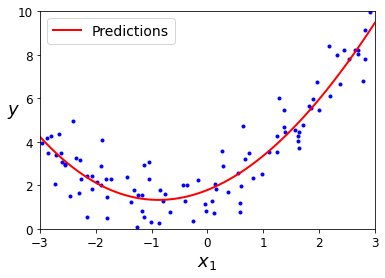

In [102]:
# Polynomial Regression model predictions

X_new = np.linspace(-3, 3, 100).reshape(100, 1)
X_new_poly = poly_features.transform(X_new)
y_new = lin_reg.predict(X_new_poly)
plt.plot(X, y, "b.")
plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.legend(loc="upper left", fontsize=14)
plt.axis([-3, 3, 0, 10])
plt.show()

# Learning Curves

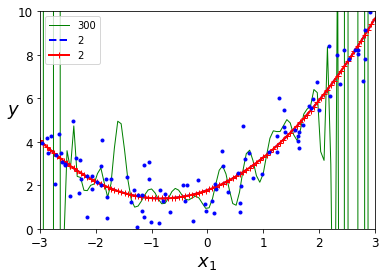

In [103]:
# High degree polynimials

from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

for style, width, degree in (("g-", 1, 300), ("b--", 2, 2), ("r-+", 2, 2)):
    polybig_features = PolynomialFeatures(degree=degree, include_bias=False)
    std_scaler = StandardScaler()
    lin_reg = LinearRegression()
    polynomial_regression = Pipeline([
        ("poly_features", polybig_features),
        ("std_scaler", std_scaler),
        ("lin_reg", lin_reg)
        ])
    polynomial_regression.fit(X, y)
    y_newbig = polynomial_regression.predict(X_new)
    plt.plot(X_new, y_newbig, style, label=str(degree), linewidth=width)

plt.plot(X, y, "b.", linewidth=3)
plt.legend(loc="upper left")
plt.xlabel("$x_1$", fontsize=18)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.axis([-3, 3,0,10])
plt.show()

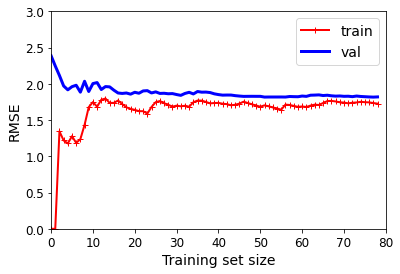

In [104]:
# Learning curves of the plain Linear Regression model

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

def plot_learning_curves(model, X, y):
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=10)
    train_errors, val_errors = [], []
    for m in range(1, len(X_train)):
        model.fit(X_train[:m], y_train[:m])
        y_train_predict = model.predict(X_train[:m])
        y_val_predict = model.predict(X_val)
        train_errors.append(mean_squared_error(y_train_predict, y_train[:m]))
        val_errors.append(mean_squared_error(y_val_predict, y_val))
        
    plt.plot(np.sqrt(train_errors), "r-+", linewidth=2, label="train")
    plt.plot(np.sqrt(val_errors), "b-", linewidth=3, label="val")
    plt.legend(loc="upper right", fontsize=14)
    plt.xlabel("Training set size", fontsize=14)
    plt.ylabel("RMSE", fontsize=14)
    
lin_reg = LinearRegression()
plot_learning_curves(lin_reg, X, y)
plt.axis([0, 80, 0, 3])
plt.show()

# Regularized models

In [105]:
import numpy as np
from sklearn.linear_model import LinearRegression


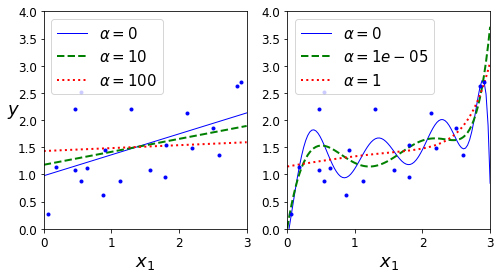

In [106]:
# Ridge Regression
# On the left is Plain Ridge Models, leading to linear predictions
# On the right the data is first expanded using PolynomialFeatures()
# then it is scaled using a StandardScaler and 
# finally the Ridge models are applied to the resulting features

import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.linear_model import Ridge

np.random.seed(42)
m = 20
X = 3 * np.random.rand(m, 1)
y = 1 + 0.5 * X + np.random.randn(m, 1) / 1.5
X_new = np.linspace(0, 3, 100).reshape(100, 1)

def plot_model(model_class, polynomial, alphas, **model_kargs):
    for alpha, style in zip(alphas, ("b-", "g--", "r:")):
        model = model_class(alpha, **model_kargs) if alpha>0 else LinearRegression()
        if polynomial:
            model = Pipeline([
                ("poly_features", PolynomialFeatures(degree=10, include_bias=False)),
                ("std_scaler", StandardScaler()),
                ("regul_reg", model),
                
            ])
        model.fit(X, y)
        y_new_regul = model.predict(X_new)
        lw = 2 if alpha > 0 else 1
        plt.plot(X_new, y_new_regul, style, linewidth=lw, label=r"$\alpha={}$".format(alpha))
    plt.plot(X, y, "b.", linewidth=3)
    plt.legend(loc="upper left", fontsize=15)
    plt.xlabel("$x_1$", fontsize=18)
    plt.axis([0, 3, 0, 4])
    
plt.figure(figsize = (8, 4))
plt.subplot(121)
plot_model(Ridge, polynomial=False, alphas=(0, 10, 100), random_state=42)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.subplot(122)
plot_model(Ridge, polynomial=True, alphas=(0, 10**-5, 1), random_state=42)
plt.show()


In [107]:
# Ridge Regression with Scikit-Learn using a closed-form solution

from sklearn.linear_model import Ridge

ridge_reg = Ridge(alpha=1, solver="cholesky", random_state=42)
ridge_reg.fit(X, y)
ridge_reg.predict([[1.5]])

array([[1.55071465]])

In [108]:
# Ridge Regression with Scikit-Learn using SGD

sgd_reg = SGDRegressor(penalty="l2", random_state=42)
sgd_reg.fit(X, y.ravel())
sgd_reg.predict([[1.5]])

array([1.47012588])

In [109]:
# Ridge Regression with Scikit-Learn using Stochastic Average GD

ridge_reg = Ridge(alpha=1, solver="sag", random_state=42)
ridge_reg.fit(X, y.ravel())
ridge_reg.predict([[1.5]])

array([1.5507201])

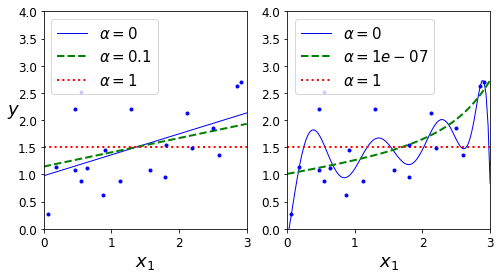

In [110]:
# Lasso Regression for different values of Alpha
# On the left in plain Linear Regression
# On the right is Polynomial Regression

from sklearn.linear_model import Lasso, LinearRegression

plt.figure(figsize=(8, 4))
plt.subplot(121)
plot_model(Lasso, polynomial=False, alphas=(0, 0.1, 1), random_state=42)
plt.ylabel("$y$", rotation=0, fontsize=18)
plt.subplot(122)
plot_model(Lasso, polynomial=True, alphas=(0, 10**-7, 1), tol=1, random_state=42)
plt.show()

In [111]:
#Lasso Regression using Scikit-Learn

from sklearn.linear_model import Lasso
lasso_reg = Lasso(alpha=0.1)
lasso_reg.fit(X, y)
lasso_reg.predict([[1.5]])

array([1.53788174])

In [112]:
# Elastic Net
# l1_ratio corresponds to the mix ratio r

from sklearn.linear_model import ElasticNet
elastic_net = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)
elastic_net.fit(X, y)
elastic_net.predict([[1.5]])

array([1.54333232])

In [113]:
import numpy as np

u = np.array([2, 5])
v = np.array([3, 1])

xcoords, ycoords = zip(u, v) # zip pairs elements position-wise:

print(xcoords)
print(ycoords)

(2, 3)
(5, 1)


In [114]:
# If u.v = 0 where u and v are vectors, Which of these can be said for sure?
# The vectors u and v are orthogonal

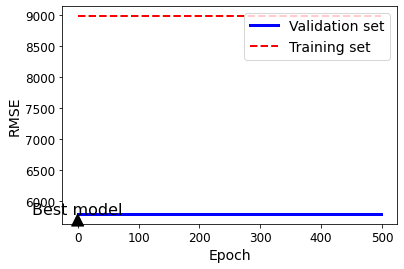

In [115]:
# Early stopping regularization on a high-degree Polynmial Regression

np.random.seed(42)
m=100
X = 6 * np.random.rand(m, 1) - 3
y = 2 + X + 0.5 * X**2 + np.random.randn(m, 1)

X_train, X_val, y_train, y_val = train_test_split(X[:50], y[:50].ravel(), test_size=0.5, random_state=10)

poly_scaler = Pipeline([
    ("poly_features", PolynomialFeatures(degree=90, include_bias=False)),
    ("std_scaler", StandardScaler()),
])

X_train_poly_scaled = poly_scaler.fit_transform(X_train)
X_val_poly_scaled = poly_scaler.transform(X_val)

sgd_Reg = SGDRegressor(max_iter=1, 
                       penalty=None, 
                       eta0=0.0005, # learning curve
                       warm_start=True, # remember the past
                       learning_rate="constant", # learning rate will not change by giving constant. 
                       # we cann give any function if want to change learning rate
                       random_state=42)

n_epochs = 500
train_errors, val_errors = [], []
for epoch in range(n_epochs):
    sgd_reg.fit(X_train_poly_scaled, y_train)
    y_train_predict = sgd_reg.predict(X_train_poly_scaled)
    y_val_predict = sgd_reg.predict(X_val_poly_scaled)
    train_errors.append(mean_squared_error(y_train_predict, y_train))
    val_errors.append(mean_squared_error(y_val_predict, y_val))
    
best_epoch = np.argmin(val_errors)
best_val_rmse = np.sqrt(val_errors[best_epoch])

plt.annotate('Best model', 
             xy = (best_epoch, best_val_rmse),
             xytext=(best_epoch, best_val_rmse + 1),
             ha="center",
             arrowprops=dict(facecolor='black', shrink=0.05),
             fontsize=16
            )

best_val_rmse -= 0.03  # just to make the graph look better
plt.plot([0, n_epochs], [best_val_rmse, best_val_rmse], "k:", linewidth=2)
plt.plot(np.sqrt(val_errors), "b-", linewidth=3, label="Validation set")
plt.plot(np.sqrt(train_errors), "r--", linewidth=2, label="Training set")
plt.legend(loc="upper right", fontsize=14)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("RMSE", fontsize=14)
plt.show()

In [116]:
# Basic implementation of early stopping
# with warm_start=True, when the fit() method is called, it just continue
# off instead of restarting frm scratch

from sklearn.base import clone
sgd_reg = SGDRegressor(max_iter=1, warm_start=True, penalty=None, learning_rate="constant", eta0=0.0005, random_state=42)

minimum_val_error = float("inf")
best_epoch = None
best_model = None
for epoch in range(1000):
    sgd_reg.fit(X_train_poly_scaled, y_train) # continues where it 
    y_val_predict = sgd_reg.predict(X_val_poly_scaled)
    val_error = mean_squared_error(y_val_predict, y_val)
    
    if val_error < minimum_val_error:
        minimum_val_error = val_error
        best_epoch = epoch
        best_model = clone(sgd_reg) # keep a copy of current model
        last_increase = 0
    else:
        break

/usr/local/anaconda/lib/python3.6/site-packages/sklearn/linear_model/_stochastic_gradient.py:1187: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  ConvergenceWarning)
/usr/local/anaconda/lib/python3.6/site-packages/sklearn/linear_model/_stochastic_gradient.py:1187: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  ConvergenceWarning)
/usr/local/anaconda/lib/python3.6/site-packages/sklearn/linear_model/_stochastic_gradient.py:1187: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  ConvergenceWarning)
/usr/local/anaconda/lib/python3.6/site-packages/sklearn/linear_model/_stochastic_gradient.py:1187: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  ConvergenceWarning)
/usr/local/anaco

/usr/local/anaconda/lib/python3.6/site-packages/sklearn/linear_model/_stochastic_gradient.py:1187: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  ConvergenceWarning)
/usr/local/anaconda/lib/python3.6/site-packages/sklearn/linear_model/_stochastic_gradient.py:1187: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  ConvergenceWarning)
/usr/local/anaconda/lib/python3.6/site-packages/sklearn/linear_model/_stochastic_gradient.py:1187: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  ConvergenceWarning)
/usr/local/anaconda/lib/python3.6/site-packages/sklearn/linear_model/_stochastic_gradient.py:1187: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  ConvergenceWarning)
/usr/local/anaco

/usr/local/anaconda/lib/python3.6/site-packages/sklearn/linear_model/_stochastic_gradient.py:1187: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  ConvergenceWarning)
/usr/local/anaconda/lib/python3.6/site-packages/sklearn/linear_model/_stochastic_gradient.py:1187: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  ConvergenceWarning)
/usr/local/anaconda/lib/python3.6/site-packages/sklearn/linear_model/_stochastic_gradient.py:1187: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  ConvergenceWarning)
/usr/local/anaconda/lib/python3.6/site-packages/sklearn/linear_model/_stochastic_gradient.py:1187: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  ConvergenceWarning)
/usr/local/anaco

In [117]:
best_epoch, best_model

(239,
 SGDRegressor(alpha=0.0001, average=False, early_stopping=False, epsilon=0.1,
              eta0=0.0005, fit_intercept=True, l1_ratio=0.15,
              learning_rate='constant', loss='squared_loss', max_iter=1,
              n_iter_no_change=5, penalty=None, power_t=0.25, random_state=42,
              shuffle=True, tol=0.001, validation_fraction=0.1, verbose=0,
              warm_start=True))

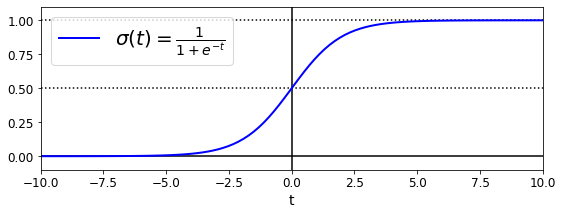

In [118]:
# plot Sigmoid function

t = np.linspace(-10, 10, 100)
sig = 1 / (1+np.exp(-t))
plt.figure(figsize=(9, 3))
plt.plot([-10, 10], [0, 0], "k-")
plt.plot([-10, 10], [0.5, 0.5], "k:")
plt.plot([-10, 10], [1, 1], "k:")
plt.plot([0, 0], [-1.1, 1.1], "k-")
plt.plot(t, sig, "b-", linewidth=2, label=r"$\sigma(t) = \frac{1}{1+e^{-t}}$")
plt.xlabel("t")
plt.legend(loc="upper left", fontsize=20)
plt.axis([-10, 10, -0.1, 1.1])
plt.show()

In [119]:
# Explore iris database

from sklearn import datasets
iris = datasets.load_iris()
list(iris.keys())

['data', 'target', 'target_names', 'DESCR', 'feature_names', 'filename']

In [120]:
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

    :Number of Instances: 150 (50 in each of three classes)
    :Number of Attributes: 4 numeric, predictive attributes and the class
    :Attribute Information:
        - sepal length in cm
        - sepal width in cm
        - petal length in cm
        - petal width in cm
        - class:
                - Iris-Setosa
                - Iris-Versicolour
                - Iris-Virginica
                
    :Summary Statistics:

    ============== ==== ==== ======= ===== ====================
                    Min  Max   Mean    SD   Class Correlation
    ============== ==== ==== ======= ===== ====================
    sepal length:   4.3  7.9   5.84   0.83    0.7826
    sepal width:    2.0  4.4   3.05   0.43   -0.4194
    petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
    petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
    ============== ==== ==== ======= ===== ===========

In [121]:
print(iris.data)

[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]
 [5.4 3.7 1.5 0.2]
 [4.8 3.4 1.6 0.2]
 [4.8 3.  1.4 0.1]
 [4.3 3.  1.1 0.1]
 [5.8 4.  1.2 0.2]
 [5.7 4.4 1.5 0.4]
 [5.4 3.9 1.3 0.4]
 [5.1 3.5 1.4 0.3]
 [5.7 3.8 1.7 0.3]
 [5.1 3.8 1.5 0.3]
 [5.4 3.4 1.7 0.2]
 [5.1 3.7 1.5 0.4]
 [4.6 3.6 1.  0.2]
 [5.1 3.3 1.7 0.5]
 [4.8 3.4 1.9 0.2]
 [5.  3.  1.6 0.2]
 [5.  3.4 1.6 0.4]
 [5.2 3.5 1.5 0.2]
 [5.2 3.4 1.4 0.2]
 [4.7 3.2 1.6 0.2]
 [4.8 3.1 1.6 0.2]
 [5.4 3.4 1.5 0.4]
 [5.2 4.1 1.5 0.1]
 [5.5 4.2 1.4 0.2]
 [4.9 3.1 1.5 0.2]
 [5.  3.2 1.2 0.2]
 [5.5 3.5 1.3 0.2]
 [4.9 3.6 1.4 0.1]
 [4.4 3.  1.3 0.2]
 [5.1 3.4 1.5 0.2]
 [5.  3.5 1.3 0.3]
 [4.5 2.3 1.3 0.3]
 [4.4 3.2 1.3 0.2]
 [5.  3.5 1.6 0.6]
 [5.1 3.8 1.9 0.4]
 [4.8 3.  1.4 0.3]
 [5.1 3.8 1.6 0.2]
 [4.6 3.2 1.4 0.2]
 [5.3 3.7 1.5 0.2]
 [5.  3.3 1.4 0.2]
 [7.  3.2 4.7 1.4]
 [6.4 3.2 4.5 1.5]
 [6.9 3.1 4.

In [122]:
print(iris.feature_names)

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [123]:
print(iris.target)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [124]:
# Train a Logistic Regression model
# To detect the Iris-Virginica type based only on the petal width feature

import numpy as np

X = iris["data"][:, 3:] # petal width
y = (iris["target"] == 2).astype(np.int) # 1 if Iris-Virginica, else 0

from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(random_state=42)
log_reg.fit(X, y)



LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='auto', n_jobs=None, penalty='l2',
                   random_state=42, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

In [125]:
log_reg.predict([[1.0]])

array([0])

/usr/local/anaconda/lib/python3.6/site-packages/matplotlib/patches.py:1338: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray
  verts = np.dot(coords, M) + (x + dx, y + dy)


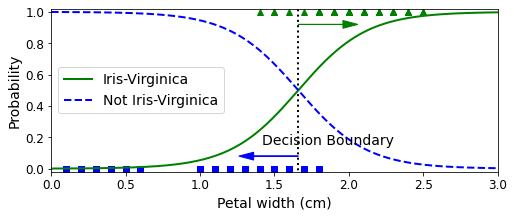

In [127]:
# Model's estimated probabilities for flowers with petal widths varying from 0 to 3 cm

X_new = np.linspace(0, 3, 1000).reshape(-1, 1)
y_proba = log_reg.predict_proba(X_new)
decision_boundary = X_new[y_proba[:,1]>=0.5][0]

plt.figure(figsize=(8, 3))
plt.plot(X[y==0], y[y==0],"bs")
plt.plot(X[y==1], y[y==1], "g^")
plt.plot([decision_boundary, decision_boundary], [-1, 2], "k:", linewidth=2)
plt.plot(X_new, y_proba[:, 1], "g-", linewidth=2, label="Iris-Virginica")
plt.plot(X_new, y_proba[:, 0], "b--", linewidth=2, label="Not Iris-Virginica")
plt.text(decision_boundary+0.2, 0.15, "Decision Boundary", fontsize=14, color="k", ha="center")
plt.arrow(decision_boundary, 0.08, -0.3, 0, head_width=0.05, head_length=0.1, fc='b', ec='b')
plt.arrow(decision_boundary, 0.92, 0.3, 0, head_width=0.05, head_length=0.1, fc='g', ec='g')
plt.xlabel("Petal width (cm)", fontsize=14)
plt.ylabel("Probability", fontsize=14)
plt.legend(loc="center left", fontsize=14)
plt.axis([0,3,-0.02, 1.02])
plt.show()

In [128]:
# decision boundary

decision_boundary

array([1.66066066])

In [129]:
# check the predictions

log_reg.predict([[1.7], [1.5]])

array([1, 0])

In [130]:
x0, x1 = np.meshgrid(
            np.linspace(2.9, 7, 500).reshape(-1,1),
            np.linspace(0.8, 2.7, 200).reshape(-1, 1)
)

In [131]:
iris.data

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1],
       [5.4, 3.7, 1.5, 0.2],
       [4.8, 3.4, 1.6, 0.2],
       [4.8, 3. , 1.4, 0.1],
       [4.3, 3. , 1.1, 0.1],
       [5.8, 4. , 1.2, 0.2],
       [5.7, 4.4, 1.5, 0.4],
       [5.4, 3.9, 1.3, 0.4],
       [5.1, 3.5, 1.4, 0.3],
       [5.7, 3.8, 1.7, 0.3],
       [5.1, 3.8, 1.5, 0.3],
       [5.4, 3.4, 1.7, 0.2],
       [5.1, 3.7, 1.5, 0.4],
       [4.6, 3.6, 1. , 0.2],
       [5.1, 3.3, 1.7, 0.5],
       [4.8, 3.4, 1.9, 0.2],
       [5. , 3. , 1.6, 0.2],
       [5. , 3.4, 1.6, 0.4],
       [5.2, 3.5, 1.5, 0.2],
       [5.2, 3.4, 1.4, 0.2],
       [4.7, 3.2, 1.6, 0.2],
       [4.8, 3.1, 1.6, 0.2],
       [5.4, 3.4, 1.5, 0.4],
       [5.2, 4.1, 1.5, 0.1],
       [5.5, 4.2, 1.4, 0.2],
       [4.9, 3

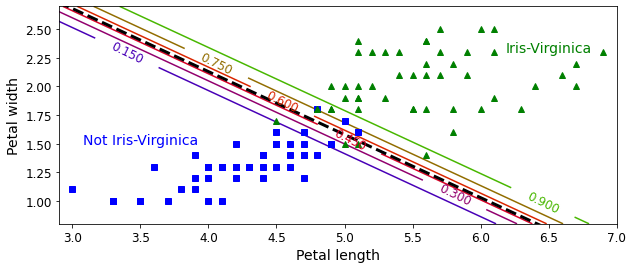

In [132]:
# Train a Logistic Regression model
# To detect the Iris-Virginica type based on the petal width and length features

from sklearn.linear_model import LogisticRegression

X = iris["data"][:, (2, 3)] # petal length, petal width
y = (iris["target"]==2).astype(np.int)

log_reg = LogisticRegression(C=10**10, random_state=42)
log_reg.fit(X, y)

x0, x1 = np.meshgrid(
            np.linspace(2.9, 7, 500).reshape(-1, 1),
            np.linspace(0.8, 2.7, 200).reshape(-1,1),
            )
X_new = np.c_[x0.ravel(), x1.ravel()]
y_proba = log_reg.predict_proba(X_new)

plt.figure(figsize=(10, 4))
plt.plot(X[y==0, 0], X[y==0, 1], "bs")
plt.plot(X[y==1, 0], X[y==1,1], "g^")

zz = y_proba[:, 1].reshape(x0.shape)
contour = plt.contour(x0, x1, zz, cmap=plt.cm.brg)

left_right = np.array([2.9, 7])
boundary = -(log_reg.coef_[0][0] * left_right + log_reg.intercept_[0]) / log_reg.coef_[0][1]

plt.clabel(contour, inline=1, fontsize=12)
plt.plot(left_right, boundary, "k--", linewidth=3)
plt.text(3.5, 1.5, "Not Iris-Virginica", fontsize=14, color="b", ha="center")
plt.text(6.5, 2.3, "Iris-Virginica", fontsize=14, color="g", ha="center")
plt.xlabel("Petal length", fontsize=14)
plt.ylabel("Petal width", fontsize=14)
plt.axis([2.9, 7, 0.8, 2.7])
plt.show()

In [133]:
# Softmax Regression

X = iris["data"][:,(2,3)] # petal length, petal width
y = iris["target"]

softmax_reg = LogisticRegression(multi_class="multinomial", solver="lbfgs", C=10, random_state=42)
softmax_reg.fit(X, y)



LogisticRegression(C=10, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='multinomial', n_jobs=None, penalty='l2',
                   random_state=42, solver='lbfgs', tol=0.0001, verbose=0,
                   warm_start=False)

In [134]:
from sklearn.metrics import confusion_matrix

y_pred = softmax_reg.predict(X)
confusion_matrix(y, y_pred)

array([[50,  0,  0],
       [ 0, 47,  3],
       [ 0,  3, 47]])

In [135]:
x1.ravel()

array([0.8, 0.8, 0.8, ..., 2.7, 2.7, 2.7])

In [136]:
# predict teh type of iris having 5 cm long and 2 cm width petal
softmax_reg.predict([[5,2]])

array([2])

In [138]:
S = np.array([5, 10, 15])
EXP = np.exp(S)

p = EXP / sum(EXP)

In [139]:
sum(p)

1.0

In [140]:
# predict the probability 

softmax_reg.predict_proba([[5, 2]])


array([[6.38014896e-07, 5.74929995e-02, 9.42506362e-01]])